<div>
<a href="https://www.audiolabs-erlangen.de/fau/professor/mueller"><img src="data_layout/PCPT_Teaser.png" width=100% style="float: right;" alt="PCPT Teaser"></a>
</div>

# Unit 9: Recursion and RNNs

<ul>
    <li><a href='#learn' style="color:#E65100;"><strong>Overview and Learning Objectives</strong></a></li> 
    <li><a href='#introRecursive' style="color:black;">Introduction to Recursive Filters</a></li>
    <li><a href='#background_recursive_fir_iir' style="color:#1B5E20;"><strong>Background:</strong> Recursive Filters, FIR/IIR, and Convolution</a></li>
    <li><a href='#intro_rnn' style="color:black;">Introduction to Recurrent Neural Networks (RNNs)</a></li>
    <li><a href='#relationship_RNN_recursive_filter' style="color:black;">Relationship between RNNs and Recursive Filters</a></li>   
    <li><a href='#rnn_pytorch' style="color:black;">RNNs in PyTorch</a></li>    
    <li><a href='#background_onset_detection' style="color:#1B5E20;"><strong>Background:</strong> Music Onset Detection</a></li>    
    <li><a href='#example_onset' style="color:black;">Example: Onset Detection </a></li>
    <li><a href='#rnn-training' style="color:black;">RNN Training</a></li>    
    <li><a href='#rnn_binary_sequence' style="color:black;">RNN Onset Detection as Binary Sequence Labeling</a></li>       
    <li><a href='#background_PRF' style="color:#1B5E20;"><strong>Background:</strong> Precision, Recall, and F-Measure
    <li><a href='#evaluation_onset_detection' style="color:black;">Evaluation: Onset Detection</a></li>     
    <li><a href='#exercise_recursive_impulse' style="color:#006064;"><strong>Exercise 1:</strong> Impulse Responses of Recursive Filters</a></li> 
    <li><a href='#exercise_weighting_pos' style="color:#006064;"><strong>Exercise 2:</strong> Class-Imbalance Weighting</a></li>    
    <li><a href='#exercise_training_prf' style="color:#006064;"><strong>Exercise 3:</strong> Exploring Model Training with PRF Reporting</a></li>            
</ul>  

<a id='learn'></a>
<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#E65100;">Overview and Learning Objectives</h2>

<p style="color:#E65100;">
This unit introduces the core idea of <strong>recurrent neural networks (RNNs)</strong> in PyTorch&mdash;models that process sequences using <strong>hidden states</strong> to carry information from one time step to the next. We begin with the concept of <strong>recursive filters</strong> from digital signal processing to show how a system can remember past inputs. From this foundation, we move on to building and training RNNs for sequence modeling. As an illustrative application, we consider <strong>onset detection</strong>, which identifies the start times of events that typically appear as sudden rises in suitably defined novelty functions. The learning objectives of this unit are as follows:
</p>

<ul style="color:#E65100;">
<li>Understand the concept of <strong>recursion</strong> by studying <strong>recursive filters</strong> in digital signal processing.</li>    
<li>Contrast <strong>FIR</strong> and <strong>IIR</strong> filters using impulse responses.</li>  
<li>Relate recursive filtering to RNN hidden-state updates, and understand the structure, role, and update mechanism of <strong>hidden states</strong> in RNNs.</li>
<li>Understand the PyTorch module <code>nn.RNN</code> and its key parameters.</li>
<li>Define a model for onset detection and prepare training/validation data with <code>NoveltyCurveDataset</code>.</li> 
<li>Train RNN models with different loss functions, including per-frame MSE and binary cross-entropy losses.</li>
<li>Use target <strong>smoothing</strong> and class weighting to address class imbalance.</li>
<li>Apply peak picking to identify onset positions in novelty curves.</li>
<li>Evaluate sequence models using frame-wise precision (P), recall (R), and F-measure (F) with tolerance, and report macro-averaged scores.</li>
</ul>

<p style="color:#E65100;">
The unit includes three hands-on exercises:
</p>
<ul style="color:#E65100;">
<li><a href="#exercise_recursive_impulse">Exercise 1</a>: Investigate the impulse responses of four simple recursive filters.</li>  
<li><a href="#exercise_weighting_pos">Exercise 2</a>: Examine positive class weighting as a strategy to handle class imbalance.</li>  
<li><a href="#exercise_training_prf">Exercise 3</a>: Refine the training pipeline for a simple RNN for onset detection to report not only losses but also event-centric P, R, and F measures.</li>  
</ul>

<p style="color:#E65100;">
For details, see the <a href="https://pytorch.org/docs/stable/nn.html#recurrent-layers" target="_blank">PyTorch documentation on recurrent layers</a>.
</p>
</div>

In [1]:
# --- Core scientific stack ---
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from torch.utils.data import DataLoader

# --- Custom utilities (Unit 9) ---
from libpcpt.unit09 import (
    plot_io,
    NoveltyCurveDataset,
    compute_prediction_dataset,
    eval_PRF,
    eval_peaks_dataset,
    mean_PRF,
    plot_peaks_stem,
    plot_prediction_example,
    plot_prediction_examples,
    visualize_training_pairs,
    exercise_recursive_impulse,
    exercise_weighting_pos,
    exercise_training_prf
)

# --- Vectorized figures ---
%config InlineBackend.figure_formats = ['svg']

<a id='introRecursive'></a>
## Introduction to Recursive Filters

A **recursive filter** is a fundamental concept in signal processing for computing a sequence of outputs where each new output depends not only on the current and past input values, but also on past output values. This gives the filter a kind of **memory**, meaning that past values can continue to influence future outputs for a long time. In the **discrete-time** case, a recursive filter can be expressed as:

$$
y(n) = \sum_{i=0}^{M} b_i\,x(n-i)\;+\;\sum_{j=1}^{N} a_j\,y(n-j).
$$

We use the following terminology:  
- $x(n)$: sample of the input signal $x$ at time $n$ 
- $y(n)$: sample of the output signal $y$ at time $n$ 
- $M$: **feedforward order** (number of past input samples used for current output) 
- $N$: **feedback order** (number of past output samples used for current output)
- $b_i$: **feedforward coefficients** (weights on input samples)  
- $a_j$: **feedback coefficients** (weights on past output samples)

In practice, we work with a finite input sequence $x=(x(0),\ldots,x(T-1))$ of length $T\in\mathbb{N}$, with samples $x(n)\in\mathbb{R}$ for $n\in\{0,1,\ldots,T-1\}$. Samples outside the observed range are set to zero: $x(n)=0$ for $n<0$ or $n\geq T$. For the output signal, we typically assume **initial rest**, meaning that $y(n)=0$ for all $n<0$ to start the recursion. With these assumptions, the first outputs are:
$$
\begin{aligned}
y(0) &= b_0\,x(0),\\
y(1) &= b_0\,x(1) + b_1\,x(0) + a_1\,y(0),\\
y(2) &= b_0\,x(2) + b_1\,x(1) + b_2\,x(0) + a_1\,y(1) + a_2\,y(0),
\end{aligned}
$$
Without initial rest, one would have to provide initial conditions $y(-1),\ldots,y(-N)$ (and, if needed, $x(-1),\ldots,x(-M)$). In practice, initial rest corresponds to left zero-padding.

The term **recursive** comes from the feedback part: to compute $y(n)$, we reuse previously computed $y$ values. If $N=0$, there is no feedback and the system is **non-recursive**; if $N>0$, feedback yields richer dynamics and longer-lasting effects. Before moving on to networks, we will examine a few simple recursive filters in NumPy to demonstrate their behavior step by step. We focus on short, easy-to-trace inputs so you can follow the recursion by hand. 

- **Echo**: `y[n] = x[n] + g * y[n-d]`  
  `g` = gain (echo strength), `d` = delay in samples.  
  Creates a delayed repetition of the input that fades over time.

- **Smoothing**: `y[n] = s * x[n] + (1-s) * y[n-1]`  
  <code>0 &lt; s &le; 1</code> controls smoothing; small `s` &rarr; smoother output.  
  Computes a weighted average of current input and previous output to reduce rapid changes.

- **Change Detector**: `y[n] = r * y[n-1] + k * (x[n] - x[n-1])`  
  `r` = persistence of change, `k` = change magnitude scaling.  
  Highlights rapid changes in the input signal while suppressing slow trends.

- **Running Sum with Decay**: `y[n] = r * y[n-1] + x[n]`  
  <code>0 &le; r &lt; 1</code> controls decay; large `r` &rarr; slow decay.  
  Accumulates the input signal over time while gradually shrinking older contributions.

In the following implementations, we zero-pad `x` and `y` wherever past values are not available. This is common in deep learning to handle missing context in sequence models or convolutions.


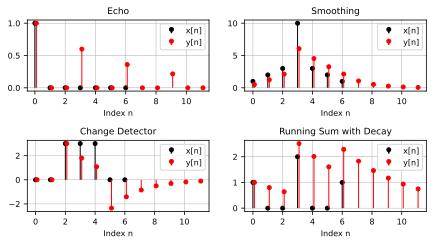

In [2]:
# 1) Echo: y[n] = x[n] + gain * y[n-delay]
def echo(x, delay=3, gain=0.6, length=None):
    T = length if length is not None else len(x)
    y = np.zeros(T, dtype=float)
    for n in range(T):
        x_n = x[n] if n < len(x) else 0.0
        y[n] = x_n + (gain * y[n - delay] if n >= delay else 0.0)
    return y

# 2) Smoothing (Exponential Moving Average): y[n] = s*x[n] + (1-s)*y[n-1]
def smoothing(x, s=0.5, length=None):
    T = length if length is not None else len(x)
    y = np.zeros(T, dtype=float)
    for n in range(T):
        x_n = x[n] if n < len(x) else 0.0
        y_prev = y[n-1] if n > 0 else 0.0
        y[n] = s * x_n + (1 - s) * y_prev
    return y

# 3) Change detector (recursive): y[n] = r*y[n-1] + k*(x[n]-x[n-1]), y[0]=0
def change_detector_recursive(x, r=0.6, k=1.0, length=None):
    T = length if length is not None else len(x)
    y = np.zeros(T, dtype=float)
    for n in range(1, T):
        x_n = x[n] if n < len(x) else 0.0
        x_prev = x[n-1] if n-1 < len(x) else 0.0
        y[n] = r * y[n-1] + k * (x_n - x_prev)
    return y

# 4) Running sum with decay: y[n] = r*y[n-1] + x[n]
def running_sum_decay(x, r=0.8, length=None):
    T = length if length is not None else len(x)
    y = np.zeros(T, dtype=float)
    for n in range(T):
        x_n = x[n] if n < len(x) else 0.0
        y_prev = y[n-1] if n > 0 else 0.0
        y[n] = r * y_prev + x_n
    return y

# ---------------- Demo ----------------
x_echo   = np.array([1, 0, 0, 0, 0, 0, 0], float)
x_smooth = np.array([1, 2, 3, 10, 3, 2, 1], float)
x_change = np.array([0, 0, 3, 3, 3, 0, 0], float)
x_sum    = np.array([1, 0, 0, 2, 0, 0, 1], float)

length_out = 12
y_echo   = echo(x_echo, delay=3, gain=0.6, length=length_out)
y_smooth = smoothing(x_smooth, s=0.5, length=length_out)
y_change = change_detector_recursive(x_change, r=0.6, k=1.0, length=length_out)
y_sum    = running_sum_decay(x_sum, r=0.8, length=length_out)

offset = 0.1
fig, axs = plt.subplots(2, 2, figsize=(6.2, 3.5))
plot_io(x_echo,   y_echo,   "Echo", ax=axs[0,0], xlim=(-0.5, 11.5), offset=offset)
plot_io(x_smooth, y_smooth, "Smoothing", ax=axs[0,1], offset=offset)
plot_io(x_change, y_change, "Change Detector", ax=axs[1,0], offset=offset)
plot_io(x_sum,    y_sum,    "Running Sum with Decay", ax=axs[1,1], offset=offset)
plt.tight_layout()
plt.show()

<a id='background_recursive_fir_iir'></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#1B5E20;">Background: Recursive Filters, FIR/IIR, and Convolution</h2>

<p style="color:#1B5E20;">
A key way to understand recursive filters is through their <strong>impulse response</strong>, which is the output produced when the input is the <strong>unit impulse</strong> $\delta : \mathbb{Z} \rightarrow \mathbb{R}$, defined by $\delta(n) = 1$ for $n = 0$ and $\delta(n) = 0$ otherwise.  
Recall from <a href="PCPT_06_convolution.html">Unit 6</a> on convolution that for any <strong>linear time-invariant (LTI)</strong> system, the impulse response $h$ fully determines the filter via convolution:
$$
y(n) = (h * x)(n) = \sum_{k \in \mathbb{Z}} h(k)\,x(n-k)
$$
for any input signal $x$. In other words, an LTI filter acts as a <strong>convolution operator</strong> with kernel $h$. In this setting, <strong>bounded-input bounded-output (BIBO) stability</strong> means that every bounded input signal produces a bounded output signal. For LTI systems, this holds exactly when the impulse response is absolutely summable:
$$
\sum_{n \in \mathbb{Z}} |h(n)| < \infty.
$$
This simple condition will be useful when comparing FIR and IIR filters. For a <strong>recursive filter</strong> of the form
$$
y(n) = \sum_{i=0}^{M} b_i \, x(n - i) \;+\; \sum_{j=1}^{N} a_j \, y(n - j),
$$
the impulse response $h$ is obtained by setting $x = \delta$ and assuming that the system is
<strong>initially at rest</strong> (i.e., all past inputs and outputs are zero for $n < 0$). In signal processing,
one can distinguish between two important types of such filters:
</p>

<ul style="color:#1B5E20;">
<li><strong>FIR (Finite Impulse Response):</strong> Occurs when the feedback order is $N = 0$ (no past outputs are used). In this case, $h(0) = b_0$, $h(1) = b_1$, $\ldots$, $h(M) = b_M$, and $h(n) = 0$ otherwise. The impulse response has finite length $M+1$, and the output can be written as a finite convolution sum. Because only finitely many coefficients of $h$ are nonzero, the absolute sum $\sum_n |h(n)|$ is always finite, so every FIR filter is BIBO stable.</li>

<li><strong>IIR (Infinite Impulse Response):</strong> Occurs when $N > 0$ (past outputs are used) and the recursion does not die out after a finite number of steps. In this case, the impulse response $h$ usually extends indefinitely in time, often decaying but not becoming exactly zero. Its shape is determined by both the feedforward coefficients $b_i$ and the feedback coefficients $a_j$, and the infinite length arises from the recursion. For such filters, BIBO stability is <strong>not automatic</strong>: it depends on the feedback coefficients $a_j$, which must not cause unbounded growth. Stability analysis is often carried out using the filter's <strong>transfer function</strong>, which is beyond the scope of this unit.</li>
</ul>

<p style="color:#1B5E20;">
In summary:
</p>
<ul style="color:#1B5E20;">
<li>Recursive filters with $N = 0$ are FIR filters, equivalent to finite convolutions.</li>
<li>Recursive filters with $N > 0$ are typically IIR filters, which can be approximated by long FIR filters if a finite convolution is required.</li>
<li>Impulse response analysis provides a direct link between the difference equation form and the convolution form of an LTI filter, and gives a simple criterion for BIBO stability.</li>
</ul>
</div>

<a id='intro_rnn'></a> 
## Introduction to Recurrent Neural Networks (RNNs)

Many of the recursions we have just explored (echo, smoothing, running sum) follow the same basic pattern: at each time step, the new output depends on the current input and on some summary of the past. A recurrent neural network (RNN) follows the same principle. It processes a sequence of input feature vectors $\mathbf{x}_0, \mathbf{x}_1, \ldots$ one step at a time $t$ and maintains a hidden state vector $\mathbf{h}_t$ that serves as its internal memory. This hidden state collects and compresses information from all previous inputs. At each time step $t$, the RNN takes the current input feature vector $\mathbf{x}_t$ and the previous hidden state vector $\mathbf{h}_{t-1}$, combines them through a learned, possibly nonlinear transformation (for example, using an activation function such as $\tanh$ or ReLU), and produces a new hidden state vector $\mathbf{h}_t$. From this hidden state vector, a separate **readout layer** computes the output feature vector $\mathbf{y}_t$. In this way, the hidden state controls how the past influences the future, while the readout layer controls how the internal memory is turned into the desired output (for example, a prediction or a classification).

To align with common RNN notation, we now slightly deviate from the notation used for the recursive filters above. We index time by $t = 0, 1, 2, \dots$ and write $\mathbf{x}_t$, $\mathbf{h}_t$, and $\mathbf{y}_t$ for the input, hidden state, and output feature vectors at time $t$. All quantities are modeled as vectors in Euclidean spaces of fixed dimension: the **input space** $\mathbb{R}^I$ (dimension $I$), the **hidden space** $\mathbb{R}^H$ (dimension $H$), and the **output space** $\mathbb{R}^O$ (dimension $O$). As before, we use an initial rest and zero-padding convention: for time indices outside the observed range, the input, hidden state, and output are set to the zero vector. We then work with three sequences of length $T$, indexed by $t \in \{0, \dots, T-1\}$:

* **Input feature sequence**: $(\mathbf{x}_0, \mathbf{x}_1, \dots, \mathbf{x}_{T-1})$ with $\mathbf{x}_t \in \mathbb{R}^I$. If needed, we extend this sequence by setting $\mathbf{x}_t = \mathbf{0}$ for $t \geq T$ (zero-padding).

* **Hidden state sequence**: $(\mathbf{h}_0, \dots, \mathbf{h}_{T-1})$ with $\mathbf{h}_t \in \mathbb{R}^H$. Under initial rest, the hidden state before the first input is $\mathbf{h}_{-1} = \mathbf{0}$.

* **Output feature sequence**: $(\mathbf{y}_0, \mathbf{y}_1, \dots, \mathbf{y}_{T-1})$ with $\mathbf{y}_t \in \mathbb{R}^O$.



A simple (vanilla) RNN updates the hidden state and computes the output using the same transformations at each time step. For every $t = 0, \dots, T-1$ it performs
$$
\mathbf{h}_t = f\bigl(W_x \mathbf{x}_t + W_h \mathbf{h}_{t-1} + \mathbf{b}_h\bigr)
$$
and then
$$
\mathbf{y}_t = W_y \mathbf{h}_t + \mathbf{b}_y.
$$
In other words, the RNN first forms a linear combination of the current input $\mathbf{x}_t$ and the previous hidden state $\mathbf{h}_{t-1}$, adds a bias vector, and then applies a nonlinearity $f$ to obtain the new hidden state vector $\mathbf{h}_t$. From this hidden state, a separate linear layer produces the output feature vector $\mathbf{y}_t$. The following learned transformations are used:

- $W_x \in \mathbb{R}^{H \times I}$ (input-to-hidden weights),
- $W_h \in \mathbb{R}^{H \times H}$ (hidden-to-hidden weights),
- $\mathbf{b}_h \in \mathbb{R}^H$ (hidden bias),
- $W_y \in \mathbb{R}^{O \times H}$ (hidden-to-output weights),
- $\mathbf{b}_y \in \mathbb{R}^O$ (output bias),
- $f$ is an element-wise activation function (e.g., ReLU or $\tanh$).

Note that the same weights and biases are shared across all time steps $t$, so the RNN processes each position in the sequence in a consistent way. Under the initial-rest convention, the hidden state before the first input is $\mathbf{h}_{-1} = \mathbf{0}$. Thus, the first few hidden states are
$$
\begin{aligned}
\mathbf{h}_0 &= f(W_x \mathbf{x}_0 + \mathbf{b}_h), \\
\mathbf{h}_1 &= f(W_x \mathbf{x}_1 + W_h \mathbf{h}_0 + \mathbf{b}_h), \\
\mathbf{h}_2 &= f(W_x \mathbf{x}_2 + W_h \mathbf{h}_1 + \mathbf{b}_h),
\end{aligned}
$$
and so on. The outputs $\mathbf{y}_t = W_y \mathbf{h}_t + \mathbf{b}_y$ are obtained by a simple affine transformation (also called a **linear readout**) from the hidden states. The overall recurrent processing scheme is summarized by the following diagram:

<div style="text-align: center;">
  <img src="data/PCPT_fig_recurrent.svg" width="530px" style="display: block; margin: auto;" alt="PCPT_fig_recurrent.svg">
</div>
<br>

In practice, RNNs are often extended beyond this basic form. They can consist of several recurrent layers stacked on top of each other, where the output sequence of one layer serves as the input sequence to the next. This layer-wise structure allows the network to capture more complex temporal dependencies and higher-level abstractions in the data. Moreover, one can use **bidirectional RNNs**, which process the sequence both forward and backward in time and then combine the two hidden representations. Such architectures are particularly useful when the entire input sequence is available and information from both past and future time steps is relevant for making predictions.

<a id='relationship_RNN_recursive_filter'></a> 
## Relationship between RNNs and Recursive Filters

We now establish the connection between RNNs and general recursive filters of the form
$$
y_t = \sum_{i=0}^{M} b_i\,x_{t-i} + \sum_{j=1}^{N} a_j\,y_{t-j}.
$$
Compared to our earlier notation for filters, we now write $x_t$ instead of $x(t)$ and use the time index $t$ to stay consistent with the RNN notation introduced above. This recursive filter equation shows that each output sample $y_t$ depends on the current and $M$ past input samples $x_t, x_{t-1}, \dots, x_{t-M}$ as well as on the $N$ past output samples $y_{t-1}, \dots, y_{t-N}$. When we reinterpret this recursive filter as a recurrent layer, the input and output signals are one-dimensional, so the corresponding dimensions are $I = O = 1$. In particular, we can treat $x_t$ and $y_t$ as scalars rather than vectors and therefore write them without boldface notation in the following.

In an RNN, the only place where past information can be stored at time $t$ is the **hidden state vector** $\mathbf{h}_t$. At the next time step $t+1$, the external input to the layer is just the current scalar $x_{t+1}$. All additional information needed to compute the next hidden state $\mathbf{h}_{t+1}$ and output $y_{t+1}$ must therefore be contained in the hidden state $\mathbf{h}_t$. Looking at the filter equation, to compute $y_{t+1}$ we need the following:

* The past outputs $y_t, y_{t-1}, \dots, y_{t-N+1}$.
* The past inputs $x_t, x_{t-1}, \dots, x_{t-M+1}$.

A natural choice is to store exactly these values in the hidden state $\mathbf{h}_t$ at time $t$. This leads to the following state vector of length $H = N + M$:
$$
\mathbf{h}_t =
\begin{bmatrix}
y_t & y_{t-1} & \cdots & y_{t-N+1} & x_t & x_{t-1} & \cdots & x_{t-M+1}
\end{bmatrix}^\top
\in \mathbb{R}^{H}.
$$

The current output sample $y_t$ is easily obtained by reading out the first entry of the hidden state vector:
$$
y_t = W_y\,\mathbf{h}_t, \qquad
W_y = \begin{bmatrix} 1 & 0 & \cdots & 0 \end{bmatrix}, \qquad
W_y \in \mathbb{R}^{1\times H}.
$$

The state update takes the form
$$
\mathbf{h}_t = W_h\,\mathbf{h}_{t-1} + W_x\,x_t,
$$
where the new state is computed from the **past** hidden state vector together with the current input, while the entries of the state vector are shifted. To replicate the behavior of the recursive filter, the matrices $W_h \in \mathbb{R}^{H\times H}$ and $W_x \in \mathbb{R}^{H\times I}$ must be set as:

$$
\underbrace{\left[\begin{array}{c}
y_t \\[2pt]
y_{t-1} \\[2pt]
y_{t-2} \\[2pt]
\vdots \\[2pt]
y_{t-N+1} \\[2pt]
\hline
x_t \\[2pt]
x_{t-1} \\[2pt]
\vdots \\[2pt]
x_{t-M+1}
\end{array}\right]}_{\text{$\mathbf{h}_t$}}
\;=\;
\underbrace{\left[
\begin{array}{ccccc|cccc}
a_1 & a_2 & \cdots & a_{N-1} & a_N & b_1 & b_2 & \cdots & b_M \\[2pt]
1   & 0   & \cdots & 0       & 0   & 0   & 0   & \cdots & 0   \\[2pt]
0   & 1   & \cdots & 0       & 0   & 0   & 0   & \cdots & 0   \\[2pt]
\vdots &   & \ddots & \vdots & \vdots & \vdots &       & \ddots & \vdots \\[2pt]
0   & 0   & \cdots & 1       & 0   & 0   & 0   & \cdots & 0   \\
\hline
0   & 0   & \cdots & 0       & 0   & 0   & 0   & \cdots & 0   \\[2pt]
0   & 0   & \cdots & 0       & 0   & 1   & 0   & \cdots & 0   \\[2pt]
\vdots &   & \ddots & \vdots  & \vdots & \vdots & \ddots & \ddots & \vdots \\[2pt]
0   & 0   & \cdots & 0       & 0   & 0   & \cdots & 1 & 0
\end{array}\right]}_{\text{$\mathbf{W}_h$}}
\;
\underbrace{\left[\begin{array}{c}
y_{t-1} \\[2pt]
y_{t-2} \\[2pt]
y_{t-3} \\[2pt]
\vdots \\[2pt]
y_{t-N} \\[2pt]
\hline
x_{t-1} \\[2pt]
x_{t-2} \\[2pt]
\vdots \\[2pt]
x_{t-M}
\end{array}\right]}_{\text{$\mathbf{h}_{t-1}$}}
\;+\;
\underbrace{\left[\begin{array}{c}
b_0 \\[2pt]
0   \\[2pt]
0   \\[2pt]
\vdots \\[2pt]
0   \\[2pt]
\hline
1   \\[2pt]
0   \\[2pt]
\vdots \\[2pt]
0
\end{array}\right]}_{\text{$\mathbf{W}_x$}}
\, x_t
$$
This demonstrates that a general recursive filter can be seen a special type of recurrent layer that has no bias terms ($\mathbf{b}_h=\mathbf{0}_H$, $b_y=0$) and no nonlinearity in the state update. This gives what is sometimes called a **linear RNN**. The update rule is best read row by row. The state vector of the previous time step, $\mathbf{h}_{t-1}$, holds past outputs $y_{t-1}, \dots, y_{t-N}$ and past inputs $x_{t-1}, \dots, x_{t-M}$, and each row updates a part of this state vector:  

* **First row** applies the main filter rule, multiplying past outputs $y_{t-1}, \dots, y_{t-N}$ by $a_1, \dots, a_N$ and past inputs $x_{t-1}, \dots, x_{t-M}$ by $b_1, \dots, b_M$.  
* **Rows 2 to $N$** shift each stored $y$ value one step down the delay line, so $y_{t-1}$ becomes $y_{t-2}$, and so forth.
* **Row $N+1$** contains only zeros, since the current input $x_t$ is added through a separate weight vector $\mathbf{W}_x$.  
* **Rows $N+2$ to $N+M$** shift each stored $x$ value one step down the delay line, so $x_{t-1}$ becomes $x_{t-2}$, and so forth.  

This matrix formulation of the recursive filter is highly structured: most entries are fixed at zero, and the nonzero entries simply implement the linear shift-and-weighting behavior of the filter. While this neatly captures the specific filter in a systematic way, it also highlights the much greater expressive power of general RNNs. In a standard RNN, the weight matrices $\mathbf{W}_h$ and $\mathbf{W}_x$ are learned freely from data, rather than being fixed to match a predetermined pattern. Furthermore, RNNs typically include nonlinear activation functions, enabling them to model a far wider range of complex, nonlinear, and context-dependent relationships than any fixed linear filter could achieve. This is one of the key reasons why RNNs are so versatile in practice.

### Example: Change Detector as RNN
To illustrate the connection, consider a simple **change detector** from our earlier examples:  
$$
y_t = r\,y_{t-1} + k\,(x_t - x_{t-1}) = k\,x_t - k\,x_{t-1} + r\,y_{t-1}
$$
with **persistence** $r$ (memory decay) and **change gain** $k$. In recursive filter notation, this means $a_1 = r$, $b_0 = k$, and $b_1 = -k$. We store both the current output $y_t$ and current input $x_t$ in the hidden state 
$$
\mathbf{h}_t =
\begin{bmatrix}
y_t & \; x_t
\end{bmatrix}^\top
\in\mathbb{R}^2,
\quad H=2.
$$
The RNN update is given by  
$$
\mathbf{h}_t = f\left(\mathbf{W}_h\,\mathbf{h}_{t-1} + \mathbf{W}_x\,\mathbf{x}_t + \mathbf{b}_h\right), 
\qquad
y_t = \mathbf{W}_y\,\mathbf{h}_t + b_y,
$$
with $\mathbf{b}_h = \mathbf{0}$, $b_y = 0$, and $f$ being the identity function. In block-matrix form:
$$
\underbrace{\left[\begin{array}{c}
y_t \\[2pt]
\hline
x_t
\end{array}\right]}_{\text{$\mathbf{h}_t$}}
\;=\;
\underbrace{\left[
\begin{array}{c|c}
r & -k \\[2pt]
\hline
0 & 0
\end{array}\right]}_{\text{$\mathbf{W}_h$}}
\;
\underbrace{\left[\begin{array}{c}
y_{t-1} \\[2pt]
\hline
x_{t-1}
\end{array}\right]}_{\text{$\mathbf{h}_{t-1}$}}
\;+\;
\underbrace{\left[\begin{array}{c}
k \\[2pt]
\hline
1
\end{array}\right]}_{\text{$\mathbf{W}_x$}}
\, x_t,
\qquad
W_y = \begin{bmatrix} 1 & 0 \end{bmatrix}.
$$  

<a id='rnn_pytorch'></a> 
## RNNs in PyTorch

We now move from theory to practice with PyTorch's built-in module `torch.nn.RNN`, which implements a **vanilla RNN**. It processes input sequences step by step, following the recurrent update from our theory almost directly:

$$
\mathbf{h}_t = f\big(\mathbf{W}_x\,\mathbf{x}_t + \mathbf{W}_h\,\mathbf{h}_{t-1} + \mathbf{b}_h\big),  
\qquad
\mathbf{y}_t = \mathbf{W}_y\,\mathbf{h}_t + \mathbf{b}_y,
$$

where $f$ is the activation function, e.g. `tanh` or `ReLU`. PyTorch uses this same structure for $\mathbf{h}_t$ but `nn.RNN` **does not** include the output mapping using $(\mathbf{W}_y, \mathbf{b}_y)$. Instead, it returns the sequence of hidden state vectors $\mathbf{h}_t$. The final output mapping can be added separately with, for example, `nn.Linear`. The following table summarizes the notation used in theory and in `nn.RNN`:

<style>
/* Force left-aligned tables in classic HTML export */
table, th, td {
    text-align: left !important;
}
</style>

<table style="width:85%; border-collapse: collapse; margin-top: 20px; margin-bottom: 20px; table-layout: fixed;">
  <colgroup>
      <col style="width:35%;">
      <col style="width:50%;">
      <col style="width:15%;">
  </colgroup>
  <thead>
      <tr style="background-color: #e3e3e3; text-align: left;">
          <th style="border: 1px solid #ccc; padding: 6px;">Theory</th>
          <th style="border: 1px solid #ccc; padding: 6px;">PyTorch name (layer <code>l0</code>)</th>
          <th style="border: 1px solid #ccc; padding: 6px;">Shape</th>
      </tr>
  </thead>
  <tbody>
      <tr style="background-color: white; transition: none;">
          <td style="border: 1px solid #ccc; padding: 6px;">$\mathbf{W}_x$ (input-to-hidden)</td>
          <td style="border: 1px solid #ccc; padding: 6px;"><code>weight_ih_l0</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(H, I)</code></td>
      </tr>
      <tr style="background-color: white; transition: none;">
          <td style="border: 1px solid #ccc; padding: 6px;">$\mathbf{W}_h$ (hidden-to-hidden)</td>
          <td style="border: 1px solid #ccc; padding: 6px;"><code>weight_hh_l0</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(H, H)</code></td>
      </tr>
      <tr style="background-color: white; transition: none;">
          <td style="border: 1px solid #ccc; padding: 6px;">$\mathbf{b}_h$ (hidden bias)</td>
          <td style="border: 1px solid #ccc; padding: 6px;"><code>bias_ih_l0</code> + <code>bias_hh_l0</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(H,)</code></td>
      </tr>
      <tr style="background-color: white; transition: none;">
          <td style="border: 1px solid #ccc; padding: 6px;">$\mathbf{W}_y$ (hidden-to-output)</td>
          <td style="border: 1px solid #ccc; padding: 6px;">weights of additional <code>nn.Linear</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(O, H)</code></td>
      </tr>
      <tr style="background-color: white; transition: none;">
          <td style="border: 1px solid #ccc; padding: 6px;">$\mathbf{b}_y$ (output bias)</td>
          <td style="border: 1px solid #ccc; padding: 6px;">bias of additional <code>nn.Linear</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(O,)</code></td>
      </tr>
  </tbody>
</table>

Note that in theory, $\mathbf{b}_h$ is a single vector. PyTorch splits it into `bias_ih_l0` (for $\mathbf{W}_x\,\mathbf{x}_t$) and `bias_hh_l0` (for $\mathbf{W}_h\,\mathbf{h}_{t-1}$) for interoperability reasons with underlying libraries. To match the theory, one just needs to sum them: `bias_ih_l0 + bias_hh_l0` to get $\mathbf{b}_h$. 

### Important RNN Parameters

RNNs in PyTorch come with many parameters that allow you to modify, stack, and build powerful recurrent models. In the following, we focus on the most important parameters of the `nn.RNN` module, before returning to our change-detector recursive filter.

- `input_size`: Dimensionality $I$ of the input space.</br>
  *Example:* `1` &rarr; Scalar input  

- `hidden_size`: Dimensionality $H$ of the hidden space.</br>
  *Example:* `2` &rarr; Storing $\mathbf{h}_t = [y_t \quad x_t]^\top$  

- `nonlinearity`: Either `'tanh'` or `'relu'`.</br>
  *Example:* `'tanh'` &rarr; Approximately the identity near zero  

- `bias` (bool): Enables or disables learnable bias terms.</br>
  *Example:* `False` &rarr; Keep the mapping purely linear  

- `batch_first` (bool): Controls the tensor layout.</br>
  *Example:* `True` &rarr; Inputs/outputs shaped as `(B, T, I)` or `(B, T, H)`  
  *Example:* `False` &rarr; Inputs/outputs shaped as `(T, B, I)` or `(T, B, H)`  
  Here, `B` is the batch size, `T` the sequence length, and `H` the hidden size.

- `num_layers`: Stacks recurrent layers; the sequence of hidden state vectors of one layer becomes the input feature sequence of the next.
- `dropout`: Applied **between** stacked layers when `num_layers > 1`.
- `bidirectional`: Simultaneously processes the input sequence in both temporal directions (non-causal; doubles the output feature dimensionality to $2H$).

When you call an `nn.RNN` layer in PyTorch, it always returns **two** tensors:

* A tensor containing the **hidden state at every time step** (often called `h_seq` or `output`).
* A tensor containing the **final hidden state** at the end of the sequence (called `h_n`).

The idea is as follows: `h_seq` is useful when you care about the entire sequence (e.g., for sequence labeling), whereas `h_n` is useful when you only need a single summary at the end (e.g., for sequence classification or when stacking multiple RNN layers). In a simple setting with `batch_first=True` and `num_layers=1`, the shapes are `(B, T, H)` for `h_seq` and `(1, B, H)` for `h_n`.

If we additionally have `bidirectional=False` (the default in our example), then `h_n` does **not** contain any new information: it is just the last time step of `h_seq`. In this case, the final hidden state can be obtained in two equivalent ways: `h_seq[:, -1, :]` and `h_n[0, :, :]`, both having shape `(B, H)`.

### Change Detector as a (Nearly) Linear RNN in PyTorch

Coming back to our change-detector example, we set `num_layers=1`, leave `dropout` unused, and keep `bidirectional=False` to preserve causality. We now re-implement the filter using `torch.nn.RNN`. However, there is a small complication: `torch.nn.RNN` only supports `tanh` and `relu` as activation functions, while we actually want a **linear** model without any nonlinearity in the state update. An identity activation is not available in `nn.RNN`. To get around this, we use a simple approximation trick. For small inputs near zero, we have
$$
\tanh(z) \approx z.
$$
We keep the pre-activation small by scaling it down with a constant factor `alpha`, so that
$$
\tanh(\alpha z) \approx \alpha z.
$$
Concretely, we scale only the input weight matrix $W_x$ inside the RNN by `alpha` and then undo this scaling in a linear readout layer after the RNN. In this way, the overall mapping behaves **approximately like a linear RNN**, while still using the built-in `tanh` nonlinearity of `torch.nn.RNN`. Below is the complete code, with detailed comments explaining each step.

In [3]:
class ChangeDetectorRNN(nn.Module):
    """
    Implements the linear recursion
        y_t = r * y_{t-1} + k * x_t - k * x_{t-1}
    using nn.RNN with tanh kept in the near-linear regime around zero.

    Hidden state: h_t = [y_t, x_t]^T  (hidden_size = 2).

    Unscaled matrices corresponding to the recursion:
      W_h = [[ r, -k],
             [  0,  0]]    # multiplies [y_{t-1}, x_{t-1}]^T

      W_x = [[ k],
             [ 1]]         # multiplies x_t

    Tanh trick:
      For small z we have tanh(z) approximately equal to z.
      So for small alpha, tanh(alpha*z) is also approximately equal to alpha*z.
      We realize a "linear RNN" by
        - scaling only W_x by alpha inside the RNN, and
        - undoing alpha in the readout:
            weight_hh = W_h
            weight_ih = alpha * W_x
            readout   = [1/alpha, 0]  (select y-component and undo alpha)

    Shapes (batch_first=True):
      x:      (B, T, 1)
      h_seq:  (B, T, 2)   # h_t = [y_t, x_t]
      y:      (B, T, 1)   # scalar output per time step
    """
    def __init__(self, k=1.0, r=0.6, alpha=0.01, batch_first=True):
        super().__init__()
        self.alpha = float(alpha)

        # RNN cell:
        # - input_size=1  (scalar x_t)
        # - hidden_size=2 (state [y_t, x_t])
        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=2,
            num_layers=1,
            nonlinearity="tanh",
            bias=True,
            batch_first=batch_first,
        )

        # Linear readout: Maps [y_t, x_t] to y_t while undoing the alpha scaling
        self.readout = nn.Linear(2, 1, bias=True)

        with torch.no_grad():
            # Recurrent matrix (unscaled)
            Wh = torch.tensor([[r, -k],
                               [0.0, 0.0]], dtype=torch.float32)
            self.rnn.weight_hh_l0.copy_(Wh)

            # Input matrix (scaled by alpha)
            Wx = torch.tensor([[self.alpha * k],
                               [self.alpha * 1.0]], dtype=torch.float32)
            self.rnn.weight_ih_l0.copy_(Wx)

            # Biases = 0 -> untrained model reproduces the recursive filter
            self.rnn.bias_ih_l0.zero_()
            self.rnn.bias_hh_l0.zero_()

            # Readout = [1/alpha, 0] -> pick y-component and undo alpha
            self.readout.weight.copy_(
                torch.tensor([[1.0 / self.alpha, 0.0]], dtype=torch.float32)
            )
            self.readout.bias.zero_()

    def forward(self, x, h0=None):
        """
        x:  (B, T, 1)   because batch_first=True
        Returns y: (B, T, 1)
        """
        if h0 is None:
            # Initial rest: y_{-1} = 0, x_{-1} = 0
            B = x.size(0)
            h0 = torch.zeros(1, B, 2, dtype=x.dtype, device=x.device)

        # h_seq holds all hidden states; separate final-state output is redundant
        h_seq, _ = self.rnn(x, h0)          # (B, T, 2), each h_t = [y_t, x_t]
        y = self.readout(h_seq)             # (B, T, 1)
        return y

# ---- Tiny demo ----
x = np.array([0, 0, 3, 3, 3, 0, 0], dtype=float)
x_torch = torch.tensor(x, dtype=torch.float32).view(1, -1, 1)  # (1, T, 1)

r_init, k_init, alpha = 0.6, 1.0, 0.01
model = ChangeDetectorRNN(k=k_init, r=r_init, alpha=alpha, batch_first=True)

with torch.no_grad():
    y_pred = model(x_torch).squeeze(0).squeeze(-1).numpy()

y_ref = change_detector_recursive(x, r=r_init, k=k_init)

print("PyTorch RNN output y_pred:")
print("[" + ", ".join(f"{v:.4f}" for v in y_pred) + "]")

print("\nReference recursion y_ref:")
print("[" + ", ".join(f"{v:.4f}" for v in y_ref) + "]")

max_diff = np.max(np.abs(y_pred - y_ref))
print(f"\nMax abs. difference: {max_diff:.4e}")

PyTorch RNN output y_pred:
[0.0000, 0.0000, 2.9991, 1.8002, 1.0810, -2.3501, -1.4100]

Reference recursion y_ref:
[0.0000, 0.0000, 3.0000, 1.8000, 1.0800, -2.3520, -1.4112]

Max abs. difference: 1.9069e-03


The RNN and the recursive filter produce almost identical outputs. The small mismatch is caused by using `tanh` inside the RNN instead of a true identity activation. By scaling the pre-activation with a small factor `alpha`, we keep `tanh(z)` in a nearly linear regime, so its behavior closely matches the desired linear recursion. Choosing a smaller `alpha` makes the agreement even tighter, but also shrinks gradients during training.

In our implementation, we have explicitly constructed the RNN weights to reproduce a known recursive filter. In practice, however, one usually does the opposite: the RNN parameters are **learned from data**, and the model discovers an effective recursion by itself. In the following, we will set up a simple application, generate training data, and train the RNN to learn the change detector from examples rather than by hand-crafted weights.

<a id='background_onset_detection'></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#1B5E20;">Background: Music Onset Detection</h2>

<p style="color:#1B5E20;">
Music onset detection asks a simple question: when does a new sound begin? This is the instant a drum is struck, a piano key is pressed, or a guitar note starts. In raw audio, the beginning is hard to see because the waveform oscillates rapidly and contains details not directly related to the onset. A common approach is to convert the signal into a one-dimensional <strong>novelty function</strong>, which is designed to respond strongly when something <strong>new</strong> happens in the sound. One simple example of such a function is an <strong>energy-based curve</strong> that increases when the signal energy suddenly rises and then decays afterwards. In this view, an onset corresponds to the point where the novelty (or energy) curve starts to climb, typically followed by a slower fall in the curve.
</p>

<p style="color:#1B5E20;">
The term <strong>onset</strong> is related to, but distinct from, <strong>attack</strong> and <strong>transient</strong>. The attack is the build-up phase of a note, usually visible as a sharply increasing energy envelope. The transient is the short, noise-like burst that often occurs at the beginning. The onset is the single time instant that marks the start of that transient, or the earliest time at which it can be reliably detected. This idea is illustrated below.<br><br>
</p>

<div style="text-align: center;">
  <img src="data/PCPT_fig_onset.svg" width="500px" style="display: block; margin: auto;" alt="PCPT_fig_onset.svg">
</div>
<br>

<p style="color:#1B5E20;">
Onset detection supports many tasks in <strong>Music Information Retrieval</strong> (<strong>MIR</strong>), including beat and tempo tracking, transcription, note segmentation, and alignment. In practice, the audio is transformed into a simple one-dimensional novelty (e.g., energy or spectral flux). Rapid changes are emphasized so that rising segments of the novelty function stand out, and peaks are then selected as onset candidates while enforcing a minimum spacing between neighboring peaks. In this unit, the idea is mirrored using synthetic novelty functions, and an RNN is trained to label exact onset positions. This keeps the problem intuitive, makes model behavior easy to inspect, and sets the stage for applying the same ideas to real audio. For a detailed treatment, see the FMP notebooks on <a href="https://audiolabs-erlangen.de/resources/MIR/FMP/C6/C6S1_OnsetDetection.html">Onset Detection</a> and the broader <a href="https://audiolabs-erlangen.de/FMP">FMP Notebooks</a>.
</p>
</div>

<a id="example_onset"></a>
## Example: Onset Detection

As a simple training task for our RNN, we use onset detection on 1D sequences that behave like novelty (or energy) curves: they stay low in steady regions and show a sudden rise followed by a decay when an event occurs. In this setting, onset detection means identifying the start times of these rises. Rather than extracting such curves from real audio, we generate them synthetically. Each event produces a sudden jump followed by an exponential decay, and we then add light noise and optional smoothing. Intuitively, our generator does the following:

* Draws events that each initiate a sudden rise and an exponential decay with a random time constant.
* Optionally softens the attack with a short ramp and jitter, then applies a light Gaussian blur.
* Samples a random amplitude for each event within a given range.
* Enforces a minimum distance between events and controls the total event count.
* Adds Gaussian noise and rescales the sequence to a fixed maximum.

The reference onset positions are encoded by a target signal. By default, this target is binary: spikes of value `1` at the true event positions and `0` elsewhere. Optionally, one can smooth the targets by replacing each spike with a unit-peak Gaussian whose width is controlled by the parameter `sigma_target` (if set). For the training examples below, we use the following generator settings: `n_samples=200` (number of sequences), `seq_len=128` (sequence length), `sigma_target=1.0` (target smoothing), and `seed=0` (fixed seed). Other generator parameters only affect the statistics and visual appearance of the signals. 

Next, we will build training and validation sets, wrap them in data loaders, and preview a few examples (inputs in gray, targets in black) before training the RNN to map energy-like curves to onset indicators. We apply light target smoothing (a small Gaussian bump around each onset) to reduce the extreme sparsity of `1` values relative to `0` values, which stabilizes gradients and typically speeds up learning.

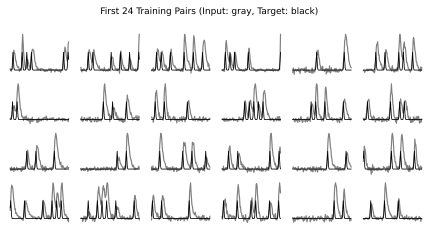

In [4]:
# Build datasets. Each dataset stores:
#   - X: (N, T, 1) input sequences (novelty-like curves)
#   - Y: (N, T, 1) targets (binary or smoothed spikes)
train_ds = NoveltyCurveDataset(n_samples=200, seq_len=128, sigma_target=1.0, seed=0)
val_ds   = NoveltyCurveDataset(n_samples=100, seq_len=128, sigma_target=1.0, seed=1)

# DataLoaders: Shuffle only the training loader; same batch size for both
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)

# Visualize a grid of input/target pairs (inputs: gray, targets: black)
t = np.arange(train_ds.X.shape[1], dtype=float)
visualize_training_pairs(t, train_ds.X[:24], train_ds.Y[:24], n_rows=4, n_cols=6,
                         title="First 24 Training Pairs (Input: gray, Target: black)")

Next, we visualize a single training example and show three curves: the input novelty (gray), the target onset signal (black), and the output of our simple change detector implemented as a recursive filter (dotted blue). This recursive filter will serve both as a baseline reference and as the initialization for our `ChangeDetectorRNN` before training.

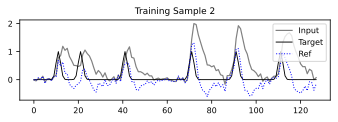

In [5]:
# Visualize one training input/target pair together with the recursive-filter output
sample_idx = 2
r_init, k_init = 0.6, 1.0
x, y = train_ds[sample_idx]
x_np = x[:, 0].numpy()
y_np = y[:, 0].numpy()
y_ref = change_detector_recursive(x_np, r=r_init, k=k_init)
plot_prediction_example(x_np, y_np, None, y_ref, 
                        title=f"Training Sample {sample_idx}")

<a id="rnn-training"></a>
## RNN Training

With onset detection and the synthetic dataset in place, we are ready to train our first RNN, motivated by and initialized from the change detector. Training an RNN is straightforward: run it over the sequence, compare its output to the target at each time step, and update the weights via backpropagation through time so the next pass is closer to the target. In our setup, the input is an energy-like novelty curve and the target marks onset beginnings. Because we start from the change-detector recursion, the untrained network already behaves like a reasonable onset detector. Training then fine-tunes the RNN's trainable parameters so its outputs better match our synthetic data. Next, we set up training as follows:

- Define `evaluate_model_loader` to compute the average loss.
- Initialize `ChangeDetectorRNN` with change-detector parameters and choose `MSELoss`.
- Report the initial training and validation loss (before any updates).
- Visualize one training example (input, target, model prediction, and recursive-filter reference) to verify the initialization.

Although onset detection is often cast as per-frame classification with BCE as the loss, here we use `MSELoss`. From a filter viewpoint, our RNN is initialized as a linear change detector, so predicting a smooth novelty curve (regression) fits better than making hard `0`/`1` decisions. This keeps the pipeline simple and interpretable: the model outputs real values directly, with no logits or sigmoid. To stabilize training, we apply light Gaussian smoothing to the targets, which reduces label sparsity and provides richer gradients while still localizing onsets clearly.

Initial loss evaluation | Train Loss: 0.0536 | Val Loss: 0.0549


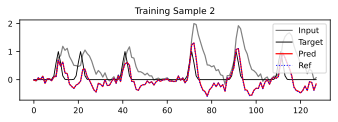

In [6]:
def evaluate_model_loader(model, loader, loss_fn, use_sigmoid=False):
    """
    Simple evaluation loop.
    Run the model on all batches in a DataLoader and return the average loss.

    Args:
        model: Maps (B, T, 1) to (B, T, 1).
        loader: DataLoader yielding batches (xb, yb).
        loss_fn: Loss function, e.g., nn.MSELoss() or nn.BCELoss().
        use_sigmoid (bool): If True, apply sigmoid to outputs before loss.

    Notes:
        - use_sigmoid=False: Pass raw model outputs to loss_fn  
          (use for MSELoss or BCEWithLogitsLoss).
        - use_sigmoid=True: Apply sigmoid to the outputs before loss_fn  
          (use for BCELoss, which expects probabilities in [0, 1]).
    """
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            yb_pred = model(xb)
            if use_sigmoid:
                yb_pred = torch.sigmoid(yb_pred)
            loss = loss_fn(yb_pred, yb)        # Compute batch loss
            total += loss.item() * xb.size(0)  # Accumulate summed loss
            n += xb.size(0)                    # Count number of samples
    return total / max(n, 1)                   # Average loss over all samples

# Initialize model and choose loss function
alpha = 0.1
r_init, k_init = 0.6, 1.0
model = ChangeDetectorRNN(k=k_init, r=r_init, alpha=alpha, batch_first=True)
loss_fn = nn.MSELoss()

# Initial evaluation (before any training)
train_loss = evaluate_model_loader(model, train_loader, loss_fn)
val_loss   = evaluate_model_loader(model, val_loader, loss_fn)
print(f"Initial loss evaluation | Train Loss: {train_loss:.4f}"
      f" | Val Loss: {val_loss:.4f}")

# Visualize one training sample, model prediction, and recursive-filter output
sample_idx = 2    
x_fix, y_fix = train_ds[sample_idx]
with torch.no_grad():
    y_fix_pred = model(x_fix.unsqueeze(0))[0, :, 0].numpy() 
x_fix_np = x_fix[:, 0].numpy()
y_fix_np = y[:, 0].numpy()
y_fix_ref = change_detector_recursive(x_fix_np, r=r_init, k=k_init)
plot_prediction_example(x_fix_np, y_fix_np, y_fix_pred, y_fix_ref, 
                        title=f"Training Sample {sample_idx}")

We now choose an optimizer and run a short training loop. At selected epochs, we print the train and validation loss and save the model's prediction on one fixed sample as a snapshot. After training, we plot all snapshots together (along with the recursive-filter reference) to see how the prediction evolves over time.

Epoch  1 | Train Loss: 0.0557 | Val Loss: 0.0453


Epoch 10 | Train Loss: 0.0260 | Val Loss: 0.0255


Epoch 20 | Train Loss: 0.0245 | Val Loss: 0.0241


Epoch 30 | Train Loss: 0.0240 | Val Loss: 0.0236


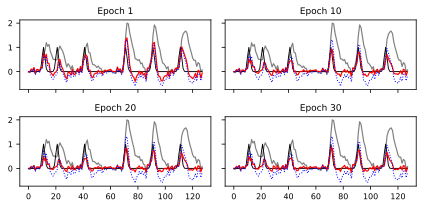

In [7]:
# Initialize model and choose loss function
alpha = 0.1
r_init, k_init = 0.6, 1.0
model = ChangeDetectorRNN(k=k_init, r=r_init, alpha=alpha, batch_first=True)
loss_fn = nn.MSELoss()

# Choose optimizer
opt = torch.optim.Adam(model.parameters(), lr=0.002) 

# Training loop (stores predictions on the fixed sample at report epochs)
snapshots = []  # list of (epoch, y_fix_pred)
epochs = 30
for epoch in range(1, epochs + 1):
    model.train()
    total, count = 0.0, 0
    for xb, yb in train_loader:
        opt.zero_grad()
        logits = model(xb)                # (batch_size, seq_len, 1)
        loss = loss_fn(logits, yb)
        loss.backward()
        opt.step()
        total += loss.item() * xb.size(0)
        count += xb.size(0)

    train_loss = total / max(count, 1)
    val_loss   = evaluate_model_loader(model, val_loader, loss_fn)

    if epoch % 10 == 0 or epoch == 1 or epoch == epochs:
        print(f"Epoch {epoch:2d} | " f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f}")
        model.eval()
        with torch.no_grad():
            y_fix_pred = model(x_fix.unsqueeze(0))[0, :, 0].numpy()
        snapshots.append((epoch, x_fix_np, y_fix_np, y_fix_pred.copy()))

fig, axs = plot_prediction_examples(snapshots, y_ref=y_fix_ref, label_title="Epoch", 
                                    cols=2, cell_size=(3, 1.5))
plt.show()

To sum up, the snapshots show that the RNN's output curve gradually approaches the target curve. The small values between events move closer to zero, and the main peaks shift toward the correct positions in time. The last three peaks almost reach height `1`, while the earlier peaks are still somewhat too low. The curve also remains a little noisy. This is perfectly reasonable. We use a mean-squared-error (MSE) loss on a slightly smoothed target curve, so the model is encouraged to spread some energy around each peak rather than produce a single sharp spike. On top of that, our RNN is very small (just one layer) and has only been trained for a short time, so we should not expect a perfect match.

This setup is intentionally simple and minimalistic to explain the training pipeline and the change-detector initialization. Stronger results are possible with a loss better suited to binary events (e.g., `BCEWithLogitsLoss`), light regularization or temporal smoothing, bidirectional context, longer training with a smaller learning rate, and richer architectures (such as `GRU`, `LSTM`, or a `CNN` combined with an `RNN`). We will explore some of these options next.

<a id="rnn_binary_sequence"></a>
## RNN Onset Detection as Binary Sequence Labeling

We now move to a **vanilla RNN** and treat onset detection as a **binary sequence labeling task**. At each time step, the model answers the yes/no question: *Is there an onset here?* The RNN uses a `tanh` activation and produces one **logit** (a real-valued score) for each time frame. For training we use `BCEWithLogitsLoss`. This combines a sigmoid with binary cross-entropy in a numerically stable way. The setup is well suited for `0`/`1` targets and often gives cleaner onset predictions than regressing a smooth curve with MSE. Compared to the earlier hand-crafted filter approach, this RNN is more flexible but also introduces new deep-learning concepts. The main points are explained below.

* **Model capacity:**  
  A vanilla RNN has a parameter called the **hidden size** (`H`), which controls how much information the model can store and relate across time. You can think of this as the number of **memory slots** available to the network. With only a few slots (for example `H=2`, as in our previous network), the model can capture only short-term cues. With more slots, it can represent longer-term patterns and more complex dependencies. Larger hidden sizes, however, also increase the risk of overfitting unless more data or regularization is used.

* **Initialization:**  
  We now start from random weights without any built-in filter-like recursion. In this setting, the RNN has no prior structure, so it must learn useful temporal patterns entirely from the training data.

* **Loss and outputs:**  
  The loss function `BCEWithLogitsLoss` takes raw logits as input and internally applies a sigmoid to obtain probabilities. During inference, probabilities are computed explicitly with `sigmoid(logit)`. A common approach for detecting onsets is to apply a threshold (for example 0.5). Frames above this threshold are marked as onset candidates. This converts continuous probabilities into discrete yes/no onset decisions.

* **Context direction:**  
  An RNN can process a sequence only forward (causal) or in both directions (bidirectional). Setting `bidirectional=True` allows the model to use information from both the past and the future at each time step. This often improves accuracy. However, it also makes the model non-causal, since the full sequence must be available. It is similar to reading a piece of music both forwards and backwards and then combining both readings to decide where the notes begin. The benefit is richer context, while the drawback is higher memory usage and a doubling of both the number of hidden states and the number of trainable parameters.

* **Class imbalance:**  
  Onsets are relatively rare: in a sequence of 1000 frames, for example, there may be 980 non-onset frames (class `0`) and only 20 onset frames (class `1`). This imbalance can lead the model to predict zeros almost everywhere, giving high accuracy but failing at onset detection. To counter this, **positive weighting** can be applied. The `pos_weight` option in `BCEWithLogitsLoss` increases the penalty for misclassifying onset frames, which means missing an onset is penalized more than mislabeling a non-onset. A common choice is to set `pos_weight` to the ratio of negatives to positives, e.g., `980 / 20 = 49`. This makes an error on an onset frame 49 times more costly than one on a non-onset frame. Internally, the loss still expects labels as `0` and `1`, but it scales the contribution of positive samples by this factor during training.

* **Target smoothing:**  
  Another helpful strategy is to soften the target labels around an onset. Instead of marking only the exact onset frame as `1`, small positive values are also assigned to neighboring frames. For example, when the original labels are `0 0 0 1 0 0 0`, the smoothed labels might look like `0 0.2 0.5 1 0.5 0.2 0`. This creates a broader and more forgiving target region, which makes learning easier and helps stabilize training, especially when onset annotations are slightly imprecise.

* **Stability:**  
  RNNs can run into the problem of exploding gradients, where training updates grow uncontrollably. A common remedy is **gradient clipping**, which sets a maximum allowed value for gradients (for example 1.0). If gradients exceed this limit, they are scaled back. This works like a speed limit that keeps training stable.

Other techniques exist, such as **dropout** (temporarily deactivating neurons during training to prevent the network from depending too strongly on specific connections) or **weight decay** (adding a penalty that keeps weights small and discourages overly complex solutions). These are not covered here, but you will encounter them in the exercises, in the comments, and in <a href="PCPT_10_essential.html">Unit 10</a> of this course.

In the next code cell, we put this RNN onset detector into practice. Everything else, including the dataset, DataLoaders, and visualization, remains unchanged. We then instantiate the model, train it with `BCEWithLogitsLoss`, and observe how its predictions evolve over time.

Epoch  1 | Train Loss: 1.1372 | Val Loss: 1.0438


Epoch  5 | Train Loss: 0.5910 | Val Loss: 0.5253


Epoch 10 | Train Loss: 0.3493 | Val Loss: 0.3271


Epoch 15 | Train Loss: 0.3085 | Val Loss: 0.3045


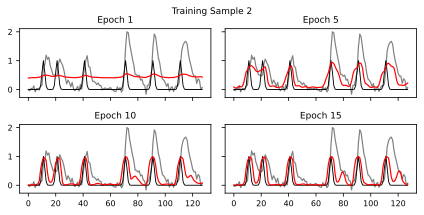

In [8]:
# ------------------------------------------------------------
# 1) Model: plain RNN (tanh) -> per-frame logits
# ------------------------------------------------------------
class SimpleTanhRNN(nn.Module):
    """
    Vanilla tanh RNN for per-frame logits.

    - Model capacity: hidden_size = H controls temporal capacity ("memory slots").
    - Initialization: Random weights; no built-in filter recursion (learn from data).
    - Outputs: Linear readout -> 1 logit per frame (pass to BCEWithLogitsLoss).
    - Context: bidirectional=True uses past and future context (2H features).
    - Shapes (batch_first=True):
        x      (B, T, 1)
        h_seq  (B, T, H) or (B, T, 2H) if bidirectional
        logits (B, T, 1)
    """
    def __init__(self, hidden_size=8, bidirectional=False, batch_first=True):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=1,
            nonlinearity="tanh",
            bias=True,
            batch_first=batch_first,
            bidirectional=bidirectional,
        )
        d = 2 if bidirectional else 1
        self.readout = nn.Linear(d * hidden_size, 1, bias=True)

    def forward(self, x, h0=None):
        h_seq, _ = self.rnn(x, h0)
        logits = self.readout(h_seq)
        return logits

# ------------------------------------------------------------
# 2) Loss: BCE with logits and class-imbalance handling
# ------------------------------------------------------------
def make_bce_loss_from_dataset(train_ds):
    """
    Compute a simple pos_weight for BCE to counter class imbalance
    (spikes are rare). Targets should be 0/1 or in [0, 1].
    """
    with torch.no_grad():
        # Fraction of positive (onset) targets; >0.5 works for binary/smoothed labels
        pos_frac = (train_ds.Y > 0.5).float().mean().item()
    ratio = (1.0 - pos_frac) / max(pos_frac, 1e-6)
    pos_weight = torch.tensor([ratio], dtype=torch.float32)            
    return nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ------------------------------------------------------------
# 3) Train loop (simple, stable defaults)
# ------------------------------------------------------------
def train_SimpleTanhRNN(
    train_loader, val_loader, train_ds, val_ds,
    hidden_size=8, bidirectional=False,
    lr=0.01, epochs=20, clip=1.0, print_every=10,
    snapshot_idx=0, weight_balance=True
):
    """
    Train SimpleTanhRNN with BCEWithLogitsLoss and capture prediction snapshots.

    Notes:
      - hidden_size controls model capacity.
      - bidirectional=True adds past and future context (non-causal).
      - Gradient clipping keeps training stable.
      - Snapshots show how predictions evolve on one fixed training sample.
      - weight_balance=True uses class weighting to counter rare positives.
    """
    model = SimpleTanhRNN(hidden_size=hidden_size, bidirectional=bidirectional)

    # Choose loss: with or without class weighting
    if weight_balance:
        loss_fn = make_bce_loss_from_dataset(train_ds)
    else:
        loss_fn = nn.BCEWithLogitsLoss()

    opt = torch.optim.Adam(model.parameters(), lr=lr)

    # Pick one fixed sample for snapshots
    x_fix, y_fix = train_ds[snapshot_idx]
    if x_fix.dim() == 1:
        x_fix = x_fix.unsqueeze(-1)
    if y_fix.dim() == 1:
        y_fix = y_fix.unsqueeze(-1)
    x_fix_np, y_fix_np = x_fix[:, 0].numpy(), y_fix[:, 0].numpy()

    snapshots = []  # list of (epoch, x_np, y_np, y_pred_np)

    for ep in range(1, epochs + 1):
        model.train()
        total, count = 0.0, 0
        for xb, yb in train_loader:
            opt.zero_grad()
            logits = model(xb)           # (B, T, 1)
            loss = loss_fn(logits, yb)   # BCE on logits
            loss.backward()
            if clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
            total += loss.item() * xb.size(0)
            count += xb.size(0)

        train_loss = total / max(count, 1)
        val_loss   = evaluate_model_loader(model, val_loader, 
                                           loss_fn, use_sigmoid=False)

        if (ep % print_every == 0) or ep == 1 or ep == epochs:
            print(f"Epoch {ep:2d} | Train Loss: {train_loss:.4f} | "
                  f"Val Loss: {val_loss:.4f}")
            model.eval()
            with torch.no_grad():
                # Sigmoid converts logits to probabilities for visualization
                y_pred = torch.sigmoid(model(x_fix.unsqueeze(0)))[0, :, 0].numpy()
            snapshots.append((ep, x_fix_np, y_fix_np, y_pred.copy()))

    return model, snapshots

# ------------------------------------------------------------
# 4) Train and visualize snapshots
# ------------------------------------------------------------
# Train and collect snapshots on one fixed example
sample_idx = 2
torch.manual_seed(0)
model, snapshots = train_SimpleTanhRNN(
    train_loader, val_loader, train_ds, val_ds,
    hidden_size=8,
    bidirectional=True,
    lr=0.01,
    epochs=15,
    clip=1.0,
    print_every=5,
    snapshot_idx=sample_idx,
    weight_balance=True,
)

# Plot snapshots (per-epoch predictions for the same sample)
fig, axs = plot_prediction_examples(snapshots, y_ref=None, label_title="Epoch", 
                                    cols=2, cell_size=(3, 1.5))
fig.suptitle(f"Training Sample {sample_idx}", fontsize=9)
fig.subplots_adjust(top=0.88)
plt.show()

As we have seen, this is a small binary sequence-labeling task, and even a compact RNN can learn it quickly. Three settings typically improve stability and speed: a **bidirectional RNN** for extra context (when non-causal inference is acceptable), **gradient clipping** to prevent exploding gradients, and **class weighting** (`pos_weight`) to compensate for rare positive frames. At the same time, the model is small and can overfit easily. The goal in this section is therefore not to chase perfect scores, but to study how these switches influence **convergence** and the **sharpness** of the onset decisions.

To probe **generalization** (under slight distribution shift), we keep the trained model fixed and systematically vary the test-set statistics. Specifically, we increase the **noise level**, alter the **event density** and **spacing**, or lengthen the **rise time**. We also combine several such modifications simultaneously to create more **extreme test conditions**.

For each setting, we visualize four examples side by side and compare the original input (grey), the target curve (black), and the prediction curve (red) across different conditions. The utility function `compute_prediction_dataset` runs the model on selected dataset samples and returns a list of tuples. Each tuple has the form `(idx, x, y_ref, y_pred)`, where `idx` is the sample index, `x` the original input, `y_ref` the target curve, and `y_pred` the predicted curve. If `indices=None`, the function processes the entire dataset and returns results for all samples.

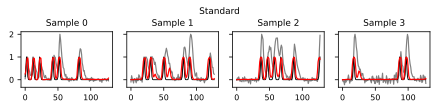

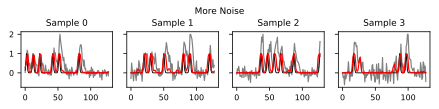

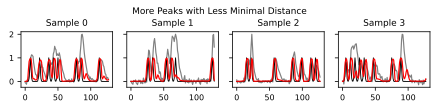

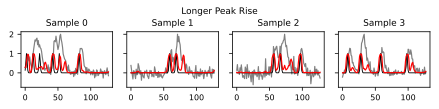

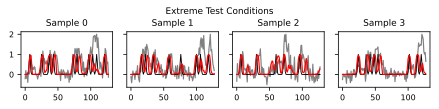

In [9]:
# Simple loop over a few pre-defined test sets (one row = 4 examples per setting)
n_samples = 4
indices = list(range(n_samples))

test_sets = [
    ("Standard",
     NoveltyCurveDataset(n_samples=n_samples, seq_len=128, sigma_target=1.0, seed=2)),

    ("More Noise",
     NoveltyCurveDataset(n_samples=n_samples, seq_len=128, sigma_target=1.0, seed=2,
                         noise_std=0.06)),

    ("More Peaks with Less Minimal Distance",
     NoveltyCurveDataset(n_samples=n_samples, seq_len=128, sigma_target=1.0, seed=2,
                         min_gap=7, n_peaks_range=(4, 8))),
    
    ("Longer Peak Rise",
     NoveltyCurveDataset(n_samples=n_samples, seq_len=128, sigma_target=1.0, seed=2, 
                         rise_len_rng=(6, 10))),

    ("Extreme Test Conditions",
     NoveltyCurveDataset(n_samples=n_samples, seq_len=128, sigma_target=1.0, seed=2, 
            min_gap=6, n_peaks_range=(5, 10), noise_std=0.06, rise_len_rng=(6, 10))),
]

for label, test_ds in test_sets:
    # Build prediction dataset: [(idx, x, y_ref, y_pred), ...]
    pred_ds = compute_prediction_dataset(model, test_ds, indices, pred='probs') 
    fig, axs = plot_prediction_examples(
        pred_ds,
        y_ref=None,
        label_title="Sample",
        cols=n_samples,
        cell_size=(1.55, 1.5)
    )
    fig.suptitle(f"{label}", fontsize=9)
    plt.tight_layout()
    fig.subplots_adjust(top=0.75)
    plt.show()

<a id='background_PRF'></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#1B5E20;">Background: Precision, Recall, and F-Measure</h2>

<p style="color:#1B5E20;">
In event detection tasks such as onset or boundary detection, the aim is to determine the precise time points at which events occur. An <strong>event</strong> is represented by a discrete time index $t \in \{0,1,\ldots,T-1\}$, and a set of events can therefore be described as a subset of this index range. We distinguish between two types of event sets: <strong>reference events</strong>, which are derived from human annotations and serve as the ground truth, and <strong>predicted events</strong> (often also called <strong>estimated events</strong>), which are generated by an algorithm, for instance through thresholding or peak-picking applied to the novelty curve produced by a machine learning model. Formally, we write
$$
B^{\mathrm{Ref}} \subseteq \{0,\ldots,T-1\}, \qquad
B^{\mathrm{Pred}} \subseteq \{0,\ldots,T-1\}.
$$
To evaluate the algorithm, we compare $B^{\mathrm{Pred}}$ against $B^{\mathrm{Ref}}$. A predicted event is considered <strong>correct</strong> only if it exactly matches a reference event. This comparison leads to three basic outcomes:
</p>

<ul style="color:#1B5E20;">
  <li><strong>True Positives </strong> are correctly detected events:  
      $\mathrm{TP} = B^{\mathrm{Pred}} \cap B^{\mathrm{Ref}} $</li>
  <li><strong>False Positives </strong> are predicted events that do not match any reference (false alarms):  
      $\mathrm{FP} = B^{\mathrm{Pred}} \setminus B^{\mathrm{Ref}} $</li>
  <li><strong>False Negatives</strong> are reference events that were missed by the algorithm:  
      $\mathrm{FN} = B^{\mathrm{Ref}} \setminus B^{\mathrm{Pred}} $</li>
</ul>

<p style="color:#1B5E20;">
From these sets, three widely used evaluation measures are derived: <strong>precision</strong> $(P)$, <strong>recall</strong> $(R)$, and the <strong>F-measure</strong> $(F)$. They are defined as  
$$
P = \frac{|\mathrm{TP}|}{|\mathrm{TP}| + |\mathrm{FP}|}, \qquad
R = \frac{|\mathrm{TP}|}{|\mathrm{TP}| + |\mathrm{FN}|}, \qquad
F = 2 \cdot \frac{P \cdot R}{P + R}.
$$
Each of these values lies between $0$ and $1$. A value of $1$ means a perfect result with respect to the corresponding criterion, while a value of $0$ means that the system completely fails on that criterion.
The precision $P$ expresses how many of the detected events are <strong>actually correct</strong>, capturing the reliability of the system. The recall $R$ expresses how many of the true events are <strong>successfully detected</strong>, capturing the completeness of the system. The F-measure then combines both aspects by taking their harmonic mean, yielding a single score that balances reliability and completeness. In practice:
</p>
<ul style="color:#1B5E20;">
  <li><strong>High precision</strong> (close to 1) means the system produces very few false alarms.</li>
  <li><strong>High recall</strong> (close to 1) means the system misses only a small number of true events.</li>
  <li><strong>High F-measure</strong> (close to 1) means the system achieves both reliability and completeness simultaneously.</li>
</ul>

<p style="color:#1B5E20;">
These measures provide a clear and interpretable way to evaluate event detection systems. However, in practice, requiring an exact match between reference and predicted events is often too strict. Small temporal deviations are common and should still be considered acceptable. To address this, one introduces a <strong>tolerance parameter</strong> $\tau \geq 0$. A predicted event $b^{\mathrm{Pred}} \in B^{\mathrm{Pred}}$ is then counted as correct if there exists a reference event $b^{\mathrm{Ref}} \in B^{\mathrm{Ref}}$ such that  
$$
| b^{\mathrm{Pred}} - b^{\mathrm{Ref}} | \leq \tau.
$$
With this generalization, the definitions of $\mathrm{TP}$, $\mathrm{FP}$, and $\mathrm{FN}$ are adapted accordingly. A challenge arises, however, because multiple predicted events may fall within the tolerance window of a single reference event, or vice versa. To avoid such ambiguities, one typically enforces a <strong>one-to-one matching</strong> between reference and predicted events. A sufficient condition to guarantee this uniqueness is to assume that successive reference and predicted events are separated by more than $2\tau$:  
$$
| b^{\mathrm{Pred}}_{k+1} - b^{\mathrm{Pred}}_{k} | \geq 2\tau + 1
\quad\text{and}\quad
| b^{\mathrm{Ref}}_{k+1} - b^{\mathrm{Ref}}_{k} | \geq 2\tau + 1
$$
Under this assumption, tolerance windows do not overlap, ensuring that each event can be matched in a clear and consistent way.
</p>
</div>


<a id="evaluation_onset_detection"></a>
## Evaluation: Onset Detection  

For onset detection, our model produces a set of predicted event positions that we compare to the annotated reference positions. As summarized in the background box, this comparison is turned into **precision**, **recall**, and **F-measure**, which quantify how reliable, how complete, and how well-balanced the detections are (each ranging between 0 and 1).

In the next cell, we use the function `eval_PRF` to illustrate how these measures are computed on a simple example. Since predicted events rarely fall exactly on the reference positions, `eval_PRF` uses a **tolerance window**: a prediction is counted as correct if it falls within this window around a reference event. To avoid counting the same event multiple times, the function enforces a **one-to-one matching** between reference and predicted events. This means that each reference event can be matched to at most one prediction, and each prediction to at most one reference. The flags `cond_ref` and `cond_pred` indicate whether this one-to-one condition is satisfied (no overlap) or whether ambiguities occurred.

In [10]:
# Example: close matches with potential ambiguities at higher tolerances
B_pred = [10, 19, 22, 38, 49, 60]   # predicted events (model outputs)
B_ref  = [10, 20, 30, 40, 46]       # reference events (ground truth)

for tol in [0, 1, 2, 3]:
    P, R, F, cond_ref, cond_pred = eval_PRF(B_ref, B_pred, tolerance=tol)
    print(f"tol={tol:2d} | P={P:.3f} | R={R:.3f} | F={F:.3f} "
          f"| cond_ref={cond_ref} | cond_pred={cond_pred}")

tol= 0 | P=0.167 | R=0.200 | F=0.182 | cond_ref=True | cond_pred=True
tol= 1 | P=0.333 | R=0.400 | F=0.364 | cond_ref=True | cond_pred=True
tol= 2 | P=0.500 | R=0.600 | F=0.545 | cond_ref=True | cond_pred=False
tol= 3 | P=0.667 | R=0.800 | F=0.727 | cond_ref=False | cond_pred=False


### From Novelty Functions to Event Positions: Peak Picking  

The RNN outputs a **novelty curve** whose values can be interpreted as probabilities associated with the individual time steps, but this does not yet provide discrete event positions. To extract events (e.g., onsets), we apply **peak picking**, which finds local maxima in the curve and decides which of them count as events. Since novelty curves often contain noise or closely spaced peaks, additional rules are needed. A simple and effective method is `scipy.signal.find_peaks`, which offers parameters to control the selection. In the following we use only two simple and directly interpretable parameters:  

- `height`: A global threshold specifying the minimal peak value. For example, `height=0.4` means only peaks above 0.4 are counted as events.  
- `distance`: The minimal horizontal spacing (in samples) between neighboring peaks. If two peaks are closer than this, the smaller one is discarded.  

In the example below, we apply these parameters to the RNN novelty curves to obtain **predicted event positions**. This then allows us to evaluate performance in terms of precision, recall, and F-measure as introduced above. By setting `distance = 2*tolerance + 1` in the peak picking for both the predicted curve (from the model) and the reference curve (from the data loader), we ensure that the sufficient conditions `cond_ref` and `cond_pred` are satisfied. Finally, we present examples from the test set under the **extreme test conditions** introduced earlier, which make the task harder by imposing a stronger distribution shift.

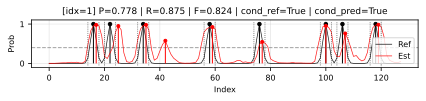

In [11]:
# Test set: "extreme" conditions to simulate a harder scenario
n_samples = 4
test_ds = NoveltyCurveDataset(n_samples=n_samples, seq_len=128, sigma_target=1.0,
   min_gap=6, n_peaks_range=(5, 10), noise_std=0.06, rise_len_rng=(6, 10), seed=2)

# Peak-picking and evaluation params
height    = 0.4                 # peak must exceed this value
tolerance = 2                   # match tolerance (± samples)
distance  = 2 * tolerance + 1   # min spacing between peaks

# Run model on the (entire) test set and pick one example
# Build prediction dataset: [(idx, x, y_ref, y_pred), ...]
pred_ds = compute_prediction_dataset(model, test_ds, indices=None, pred='probs') 
idx_sample = 1                  # position in the 'results' list
_, _, y_ref, y_pred = pred_ds[idx_sample]

# Peak picking on reference and prediction
peaks_ref,  props_ref  = find_peaks(y_ref,  height=height, distance=distance)
peaks_pred, props_pred = find_peaks(y_pred, height=height, distance=distance)

# PRF evaluation
P, R, F, cond_ref, cond_pred = eval_PRF(peaks_ref, peaks_pred, tolerance=tolerance)

# Visualization
title = (f"[idx={idx_sample}] P={P:.3f} | R={R:.3f} | F={F:.3f} | "
         f"cond_ref={cond_ref} | cond_pred={cond_pred}")
ax = plot_peaks_stem(
    y_ref, peaks_ref, props_ref,
    y_pred, peaks_pred, props_pred,
    val_min=height, tolerance=tolerance,
    title=title
)

To make these steps easier to apply, we provide two utility functions:

* `compute_prediction_dataset`: Runs the model on a dataset and returns a list of tuples `(idx, x, y_ref, y_pred)` containing the sample index, input, reference curve, and predicted curve.  
* `eval_peaks_dataset`: Applies peak picking to both reference and prediction, then computes precision, recall, F-measure, and consistency conditions for the entire dataset.

We now use these functions to inspect the results for the four samples in the **extreme test conditions** test set.

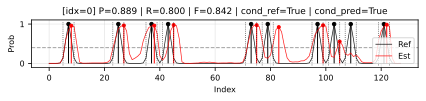

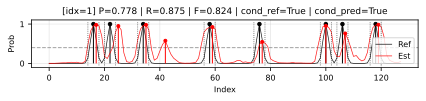

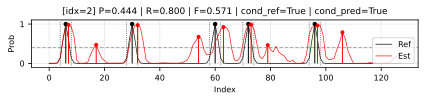

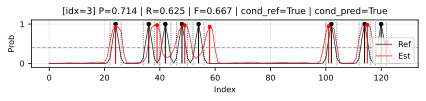

In [12]:
# Peak picking and evaluation parameters
height    = 0.4               # min peak height
tolerance = 2                 # matching tolerance (given in samples)
distance  = 2 * tolerance + 1 # min spacing between peaks

# Run model and evaluate
# compute_prediction_dataset -> [(idx, x, y_ref, y_pred), ...]
# eval_peaks_dataset -> [(idx, P, R, F, cond_ref, cond_pred, 
#                         peaks_ref, props_ref, peaks_pred, props_pred), ...]
pred_ds = compute_prediction_dataset(model, test_ds, indices=None, pred='probs')
eval_ds = eval_peaks_dataset(pred_ds, tolerance=tolerance, height=height, 
                             distance=None, plot=True, print_summary=False)

### Aggregating Evaluation Scores over a Dataset

So far, precision, recall, and F-measure have been computed for individual dataset samples. To obtain an evaluation that reflects the performance on the **entire dataset**, the scores need to be aggregated across samples. Two standard approaches are commonly used:

* **Micro-averaging:** Counts of true positives, false positives, and false negatives are pooled across all samples. From these totals, a single precision, recall, and F-measure are computed. This approach treats the dataset as one long sequence and is sensitive to event imbalance, since samples with many events contribute more strongly.

* **Macro-averaging:** Precision, recall, and F-measure are first computed for each sample individually. These values are then averaged across samples, giving each sample equal weight regardless of how many events it contains. This approach reflects performance on a **typical** sample.

In the following, macro-averaging is used for illustration by simply averaging the per-sample results across the dataset. Note that the macro-averaged F-measure is **not** the same as computing the F-measure from the macro-averaged precision and recall.

In [13]:
# Per-sample summary
for eval_sample in eval_ds:
    idx, P, R, F, cond_ref, cond_pred, _, _, _, _ = eval_sample
    print(f"Sample {idx:1d}: P={P:.3f} | R={R:.3f} | F={F:.3f} | "
          f"cond_ref={cond_ref} | cond_pred={cond_pred}")

print("-" * 70)
P_mean, R_mean, F_mean, cond_ref_all, cond_pred_all = mean_PRF(eval_ds)
print(f"MACRO:    P={P_mean:.3f} | R={R_mean:.3f} | F={F_mean:.3f} | "
      f"cond_ref={cond_ref_all} | cond_pred={cond_pred_all}")

Sample 0: P=0.889 | R=0.800 | F=0.842 | cond_ref=True | cond_pred=True
Sample 1: P=0.778 | R=0.875 | F=0.824 | cond_ref=True | cond_pred=True
Sample 2: P=0.444 | R=0.800 | F=0.571 | cond_ref=True | cond_pred=True
Sample 3: P=0.714 | R=0.625 | F=0.667 | cond_ref=True | cond_pred=True
----------------------------------------------------------------------
MACRO:    P=0.706 | R=0.775 | F=0.726 | cond_ref=True | cond_pred=True


<a id='exercise_recursive_impulse'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064;">Exercise 1: Impulse Responses of Recursive Filters</strong><br>

<p style="color:#006064;">
This exercise investigates the impulse responses of four simple recursive filters: <code>echo</code>, <code>smoothing</code>, <code>change_detector_recursive</code>, and <code>running_sum_decay</code>. The impulse response characterizes the behavior of a linear time-invariant (LTI) system and fully determines its output for any input.
</p>

<ul style="color:#006064;">
  <li>Define the impulse signal: <code>x = [1, 0, 0, 0, 0, 0, 0]</code>.</li>
  <li>For each filter, use the provided functions:
    <ul style="color:#006064;">
      <li><code>echo(x, delay=3, gain=0.6, length=12)</code></li>
      <li><code>smoothing(x, s=0.5, length=12)</code></li>
      <li><code>change_detector_recursive(x, r=0.6, k=1.0, length=12)</code></li>
      <li><code>running_sum_decay(x, r=0.8, length=12)</code></li>
    </ul>
  </li>
  <li>Plot each impulse response using the <code>plot_io</code> function. The input should be the impulse signal, and the output should be the computed response.</li>
  <li>Answer the following questions:
    <ul style="color:#006064;">
      <li>For which filters does the impulse response have finite length? Why?</li>
      <li>Which filters produce outputs that decay over time but never reach zero exactly?</li>
      <li>How do the parameters (e.g., <code>gain</code>, <code>s</code>, <code>r</code>) affect the shape of the impulse response?</li>
    </ul>
  </li>
</ul>
</div>

In [14]:
# Your Solution

== Impulse responses for Echo, Smoothing, Change Detector, Running Sum with Dec. ==


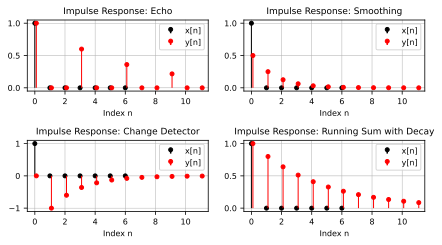


== Change detector impulse responses for different (r, k) settings ==


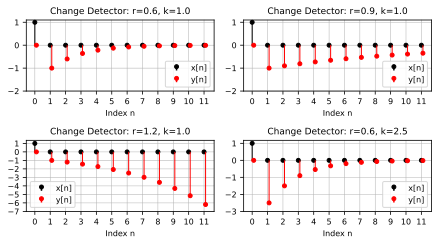

In [15]:
# Run and show output of the reference solution
exercise_recursive_impulse()

<a id='exercise_weighting_pos'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064;">Exercise 2: Class-Imbalance Weighting</strong><br>

<p style="color:#006064;">
Positive weighting is a strategy to compensate for class imbalance. In event detection tasks, only a small fraction of frames typically contain an event (labeled close to <code>1</code>), while the majority are non-events (labeled close to <code>0</code>). This imbalance can bias a model toward always predicting zeros. To address this, let <code>pos_frac</code> be the fraction of positive frames in a dataset (e.g., those with <code>label &gt; 0.5</code>) and <code>pos_weight = (1 - pos_frac) / pos_frac</code>. The rarer the positives, the larger this weight becomes, which increases the penalty for missed events. This parameter can then be passed as an option to <code>nn.BCEWithLogitsLoss(pos_weight=pos_weight)</code>. 
</p>

<p style="color:#006064;">
Create datasets <code>ds = NoveltyCurveDataset(...)</code> using different settings:
</p>

<ul style="color:#006064;">
    <li><code>sigma_target</code> (e.g., <code>{None, 0.5, 1.0, 1.5}</code>)</li> 
    <li><code>seed</code> (e.g., <code>{0, 1, 2}</code>)</li> 
    <li><code>min_gap</code> (e.g., <code>{5, 10}</code>) and <code>n_peaks_range</code> (e.g., <code>{(2, 6), (5, 10)}</code>)</li> 
</ul>

<p style="color:#006064;">
Write a small function that computes <code>pos_frac</code> and the implied <code>pos_weight</code> from the target tensor <code>ds.Y</code>. Make sure that you do not divide by zero (use a small epsilon). Vary both the target smoothing and the event statistics to see how class balance shifts. Then build the weighted loss with <code>make_bce_loss_from_dataset(ds)</code>, read the stored value via <code>loss_fn.pos_weight</code>, and compare it to your computation. Do these values and the values you computed with your own function match?
</p>
</div>

In [16]:
# Your Solution

In [17]:
# Run and show output of the reference solution
exercise_weighting_pos()

Using:
ds = NoveltyCurveDataset(n_samples=200, seq_len=128, sigma_target, min_gap, n_peaks_range, seed)
epsilon = 1e-05

sigma | min_gap | n_peaks_range | seed | pos_frac | pw_own | pw_from_loss | abs_diff
------------------------------------------------------------------------------------
None  |      10 | (3, 6)        |    0 |   0.0343 |  28.19 |        28.19 | 2.18e-07
1.0   |      10 | (3, 6)        |    0 |   0.1022 |   8.79 |         8.79 | 2.38e-07
2.0   |      10 | (3, 6)        |    0 |   0.1696 |   4.90 |         4.90 | 2.90e-08
2.0   |      10 | (3, 6)        |    1 |   0.1726 |   4.79 |         4.79 | 1.06e-07


1.0   |       5 | (3, 8)        |    0 |   0.1309 |   6.64 |         6.64 | 4.93e-08
1.0   |       5 | (5, 10)       |    0 |   0.1748 |   4.72 |         4.72 | 2.29e-07
1.0   |       5 | (8, 12)       |    0 |   0.2338 |   3.28 |         3.28 | 4.06e-08
1.0   |       5 | (8, 12)       |    1 |   0.2383 |   3.20 |         3.20 | 3.91e-09

Note: Differences between pw_own and pw_from_loss are due to different epsilon 
values used to avoid division by zero.


<a id='exercise_training_prf'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064;">Exercise 3: Exploring Model Training with PRF Reporting</strong><br>

<p style="color:#006064;">
In this exercise you will refine the training pipeline for <code>SimpleTanhRNN</code> so that it reports not only losses but also event-centric metrics: macro-averaged precision (<code>P_mean</code>), recall (<code>R_mean</code>), and F-measure (<code>F_mean</code>). These PRF scores complement the loss by showing how well predicted peaks align with reference onsets over time. As a first step, do the following:
</p>

<ul style="color:#006064;">
  <li>
Implement a function <code>evaluate_model_dataset(...)</code> with parameters <code>model</code>, <code>ds</code> (dataset), <code>tolerance=2</code>, <code>height=0.4</code>, and <code>distance=None</code> that runs inference on the dataset, applies peak picking, and returns <code>P_mean</code>, <code>R_mean</code>, and <code>F_mean</code>. If <code>distance</code> is <code>None</code>, set <code>distance = 2 * tolerance + 1</code> to encourage one-to-one matches.</li>

  <li>
    Minimally adapt <code>train_SimpleTanhRNN(...)</code> to accept <code>tolerance</code>, <code>height</code>, and <code>distance</code>. In addition to <code>train_loss</code> and <code>val_loss</code>, compute <code>train_P</code>, <code>train_R</code>, <code>train_F</code> and <code>val_P</code>, <code>val_R</code>, <code>val_F</code> via <code>evaluate_model_on_dataset</code>. Print these PRF triples at selected epochs, alongside <code>train_loss</code> and <code>val_loss</code>. Keep the rest of the function unchanged.
  </li>

  <li>
    Use the same model hyperparameters, datasets, and random seeds as before so the new run reproduces prior behavior.
  </li>
</ul>

<p style="color:#006064;">
After this, explore further by changing the training and validation <code>NoveltyCurveDataset</code> settings (e.g., <code>sigma_target</code>, <code>min_gap</code>, <code>n_peaks_range</code>, <code>noise_std</code>, <code>rise_len_rng</code>), and by experimenting with model choices (<code>hidden_size</code>, <code>bidirectional</code>, with/without class weighting). Observe how losses and PRF change. Reflect on typical trade-offs. For example, larger <code>tolerance</code> or smaller <code>height</code> may increase recall but reduce precision. Furthermore, increasing <code>sigma_target</code> enlarges positive regions, changes class balance, and can lower the implied <code>pos_weight</code>.
</p>
</div>

In [18]:
# Your Solution

Training on train_ds and validation on val_ds
PRF settings: tolerance=2, height=0.4
train_ds = NoveltyCurveDataset(n_samples=200, seq_len=128, sigma_target=1.0, seed=0)
val_ds  =  NoveltyCurveDataset(n_samples=100, seq_len=128, sigma_target=1.0, seed=1)



Ep  1 | T-L: 1.137 | V-L: 1.044 | T-PRF: 0.25/0.93/0.38 | V-PRF: 0.23/0.91/0.36


Ep  2 | T-L: 0.987 | V-L: 0.853 | T-PRF: 0.77/0.87/0.81 | V-PRF: 0.79/0.89/0.83


Ep  3 | T-L: 0.812 | V-L: 0.713 | T-PRF: 0.88/0.80/0.83 | V-PRF: 0.88/0.81/0.83


Ep  4 | T-L: 0.687 | V-L: 0.611 | T-PRF: 0.93/0.93/0.93 | V-PRF: 0.90/0.91/0.90


...

Ep 11 | T-L: 0.331 | V-L: 0.313 | T-PRF: 0.98/0.98/0.98 | V-PRF: 0.97/0.99/0.98


Ep 12 | T-L: 0.322 | V-L: 0.306 | T-PRF: 0.96/0.99/0.97 | V-PRF: 0.95/1.00/0.97


Ep 13 | T-L: 0.312 | V-L: 0.303 | T-PRF: 0.96/0.99/0.97 | V-PRF: 0.94/1.00/0.96


Ep 14 | T-L: 0.307 | V-L: 0.301 | T-PRF: 0.99/0.98/0.99 | V-PRF: 1.00/0.99/0.99


Ep 15 | T-L: 0.309 | V-L: 0.305 | T-PRF: 0.92/1.00/0.95 | V-PRF: 0.91/1.00/0.95

Plot of selected examples:



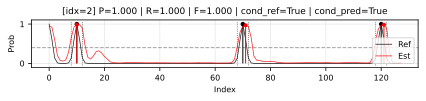

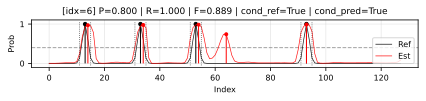

Training on train_ds_mod and validation on val_ds_mod        
PRF settings: tolerance=1, height=0.5
train_ds_mod = NoveltyCurveDataset(n_samples=200, seq_len=128, sigma_target=1.0,
    min_gap=6, n_peaks_range=(5, 8), noise_std=0.06, rise_len_rng=(2, 10), seed=0)
val_ds_mod = NoveltyCurveDataset(n_samples=100, seq_len=128, sigma_target=1.0,
    min_gap=6, n_peaks_range=(5, 8), noise_std=0.06, rise_len_rng=(2, 10), seed=1)



Ep  1 | T-L: 1.074 | V-L: 1.015 | T-PRF: 0.65/0.35/0.43 | V-PRF: 0.60/0.35/0.42


Ep  2 | T-L: 0.979 | V-L: 0.895 | T-PRF: 0.61/0.43/0.48 | V-PRF: 0.56/0.43/0.47


Ep  3 | T-L: 0.874 | V-L: 0.826 | T-PRF: 0.58/0.43/0.47 | V-PRF: 0.53/0.44/0.46


Ep  4 | T-L: 0.805 | V-L: 0.761 | T-PRF: 0.57/0.63/0.58 | V-PRF: 0.54/0.62/0.56


...

Ep 11 | T-L: 0.581 | V-L: 0.570 | T-PRF: 0.67/0.84/0.73 | V-PRF: 0.65/0.83/0.72


Ep 12 | T-L: 0.571 | V-L: 0.558 | T-PRF: 0.69/0.84/0.74 | V-PRF: 0.68/0.84/0.74


Ep 13 | T-L: 0.560 | V-L: 0.546 | T-PRF: 0.74/0.85/0.78 | V-PRF: 0.74/0.85/0.78


Ep 14 | T-L: 0.552 | V-L: 0.539 | T-PRF: 0.77/0.85/0.80 | V-PRF: 0.76/0.85/0.79


Ep 15 | T-L: 0.547 | V-L: 0.534 | T-PRF: 0.76/0.86/0.80 | V-PRF: 0.75/0.85/0.79

Plot of selected examples:



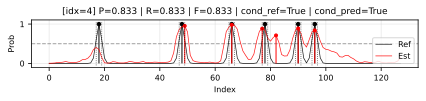

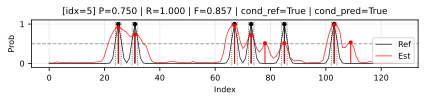

In [19]:
# Run and show output of the reference solution
exercise_training_prf()

<div>
<a href="https://opensource.org/licenses/MIT"><img src="data_layout/PCPT_License.png" width=100% style="float: right;" alt="PCPT License"></a>
</div>